# Preanálisis del TFG

En este notebook preparo la base de datos y realizo un primer preanálisis sobre el posible impacto del shock externo asociado a la muerte del papa y la elección de León XIV. El objetivo es observar, entre marzo y julio de 2025, cómo evolucionan la religiosidad, la práctica religiosa, la intención de voto y la agenda de principales problemas.

El análisis es todavía descriptivo y exploratorio. Por tanto, interpreto los resultados como asociaciones temporales, no como evidencia causal definitiva.

## Preparación inicial de la base

Primero cargo `df_total.csv` y preparo algunas variables necesarias para el análisis: convierto `Ideologia` a escala numérica, unifico el identificador individual en una sola columna `id` y construyo la variable binaria `religiosidad_si_no`.

In [1]:
from pathlib import Path

import pandas as pd

def find_data_path(filename="df_total.csv"):
    for folder in [Path.cwd(), *Path.cwd().parents]:
        candidate = folder / "data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"No encuentro data/{filename} desde {Path.cwd()}")

DATA_PATH = find_data_path()

df_total = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

df_total.head()

,Mes/Año,Id,CCAA,Poblacion_municipio,Sexo,Edad,Ideologia,Religiosidad,Practica_religion,Estudios,...,Partido_cercano,Intencion_voto,Intencion_voto_alternativo,Simpatia,Voto_simpatia,Recuerdo_voto_2023,Problema_1,Problema_2,Problema_3,Id_unico
0,03/2025,28203,Andalucía,10.001 a 50.000 habitantes,Hombre,45,5,"Indiferente, no creyente",N.P.,Primaria,...,Ninguno,No votaría,N.P.,Ninguno,Ninguno,N.P.,El mal comportamiento de los/as políticos/as,"La crisis económica, los problemas de índole e...",La inmigración,03/2025_28203
1,03/2025,63387,Andalucía,10.001 a 50.000 habitantes,Mujer,60,1 Izquierda,Católico/a no practicante,Nunca,Secundaria 1ª etapa,...,PSOE,No sabe todavía,N.P.,PSOE,PSOE,PSOE,Los problemas políticos en general,El mal comportamiento de los/as políticos/as,La inmigración,03/2025_63387
2,03/2025,74875,Andalucía,10.001 a 50.000 habitantes,Hombre,60,3,Católico/a no practicante,Casi nunca,Superiores,...,PSOE,PSOE,(NO LEER) No votaría a ningún otro partido (ci...,N.P.,PSOE,PSOE,"Las desigualdades, incluida la de género, dife...",La vivienda,La sanidad,03/2025_74875
3,03/2025,10108,Andalucía,10.001 a 50.000 habitantes,Hombre,43,4,Católico/a no practicante,Varias veces al año,Secundaria 1ª etapa,...,PSOE,PSOE,NaN,N.P.,PSOE,PSOE,Los problemas relacionados con la juventud. Fa...,La sanidad,La inmigración,03/2025_10108
4,03/2025,3233,Andalucía,100.001 a 400.000 habitantes,Mujer,38,10 Derecha,Católico/a no practicante,Varias veces al año,Secundaria 1ª etapa,...,VOX,VOX,Se Acabó la Fiesta,N.P.,VOX,PACMA,El Gobierno y partidos o políticos/as concreto...,La inmigración,El paro,03/2025_3233


Aquí convierto `Ideologia` a una escala numérica para poder trabajarla de forma homogénea en toda la base.


In [2]:
df_total["Ideologia"] = pd.to_numeric(
    df_total["Ideologia"].replace({
        "1 Izquierda": "1",
        "10 Derecha": "10",
    }),
    errors="raise",
).astype("Int64")

df_total["Ideologia"].value_counts().sort_index()

Ideologia
1     2142
2     1341
3     2847
4     2104
5     4518
6     1935
7     1742
8     1281
9      306
10    1113
Name: count, dtype: Int64

En esta celda dejo un único identificador individual y simplifico su nombre a `id`.


In [3]:
df_total = df_total.drop(columns=["Id"]).rename(columns={"Id_unico": "id"})

df_total[["id"]].head()

,id
0,03/2025_28203
1,03/2025_63387
2,03/2025_74875
3,03/2025_10108
4,03/2025_3233


Ahora recoloco `id` al principio de la base para que la tabla quede más ordenada.


In [4]:
columnas = list(df_total.columns)
columnas.remove("id")
columnas.insert(1, "id")

df_total = df_total[columnas]

df_total.head()

,Mes/Año,id,CCAA,Poblacion_municipio,Sexo,Edad,Ideologia,Religiosidad,Practica_religion,Estudios,...,Participacion_2023,Partido_cercano,Intencion_voto,Intencion_voto_alternativo,Simpatia,Voto_simpatia,Recuerdo_voto_2023,Problema_1,Problema_2,Problema_3
0,03/2025,03/2025_28203,Andalucía,10.001 a 50.000 habitantes,Hombre,45,5,"Indiferente, no creyente",N.P.,Primaria,...,No votó,Ninguno,No votaría,N.P.,Ninguno,Ninguno,N.P.,El mal comportamiento de los/as políticos/as,"La crisis económica, los problemas de índole e...",La inmigración
1,03/2025,03/2025_63387,Andalucía,10.001 a 50.000 habitantes,Mujer,60,1,Católico/a no practicante,Nunca,Secundaria 1ª etapa,...,Votó,PSOE,No sabe todavía,N.P.,PSOE,PSOE,PSOE,Los problemas políticos en general,El mal comportamiento de los/as políticos/as,La inmigración
2,03/2025,03/2025_74875,Andalucía,10.001 a 50.000 habitantes,Hombre,60,3,Católico/a no practicante,Casi nunca,Superiores,...,Votó,PSOE,PSOE,(NO LEER) No votaría a ningún otro partido (ci...,N.P.,PSOE,PSOE,"Las desigualdades, incluida la de género, dife...",La vivienda,La sanidad
3,03/2025,03/2025_10108,Andalucía,10.001 a 50.000 habitantes,Hombre,43,4,Católico/a no practicante,Varias veces al año,Secundaria 1ª etapa,...,Votó,PSOE,PSOE,NaN,N.P.,PSOE,PSOE,Los problemas relacionados con la juventud. Fa...,La sanidad,La inmigración
4,03/2025,03/2025_3233,Andalucía,100.001 a 400.000 habitantes,Mujer,38,10,Católico/a no practicante,Varias veces al año,Secundaria 1ª etapa,...,Votó,VOX,VOX,Se Acabó la Fiesta,N.P.,VOX,PACMA,El Gobierno y partidos o políticos/as concreto...,La inmigración,El paro


A continuación construyo la variable binaria de religiosidad que voy a usar después en el análisis.


In [5]:
religiosidad_catolica = [
    "Católico/a practicante",
    "Católico/a no practicante",
]

df_total["religiosidad_si_no"] = df_total["Religiosidad"].isin(religiosidad_catolica).astype(int)

df_total[["Religiosidad", "religiosidad_si_no"]].head()

,Religiosidad,religiosidad_si_no
0,"Indiferente, no creyente",0
1,Católico/a no practicante,1
2,Católico/a no practicante,1
3,Católico/a no practicante,1
4,Católico/a no practicante,1


Aquí compruebo que la recodificación de `religiosidad_si_no` haya quedado bien.


In [6]:
pd.crosstab(df_total["Religiosidad"], df_total["religiosidad_si_no"])

religiosidad_si_no,0,1
Religiosidad,,
Agnóstico/a (no niegan la existencia de Dios pero tampoco la descartan),2846,0
Ateo/a (niegan la existencia de Dios),3375,0
Católico/a no practicante,0,7019
Católico/a practicante,0,3502
Creyente de otra religión,561,0
"Indiferente, no creyente",2490,0


## Comprobación rápida del peso

Antes de empezar con las regresiones, hago una comprobación rápida para ver si usar `Peso` cambia mucho la foto general. Si apenas cambiara nada, tendría sentido seguir sin él. Si sí mueve algunos resultados, entonces prefiero decidirlo ya al principio y trabajar igual en todo lo que viene.


In [7]:
import numpy as np


def media_ponderada(serie, pesos):
    return np.average(serie, weights=pesos)


comparacion_peso_meses = (
    df_total.groupby("Mes/Año")
    .agg(
        n=("id", "size"),
        peso_total=("Peso", "sum"),
        religiosidad_media_simple=("religiosidad_si_no", "mean"),
    )
    .reset_index()
)

comparacion_peso_meses["religiosidad_media_ponderada"] = (
    df_total.groupby("Mes/Año")
    .apply(lambda x: media_ponderada(x["religiosidad_si_no"], x["Peso"]))
    .values
)

partidos_revision_peso = {
    "voto_psoe_revision": "PSOE",
    "voto_pp_revision": "PP",
    "voto_vox_revision": "VOX",
    "voto_sumar_revision": "Sumar",
}

for variable, partido in partidos_revision_peso.items():
    df_total[variable] = pd.NA
    df_total.loc[df_total["Intencion_voto"].notna(), variable] = 0
    df_total.loc[df_total["Intencion_voto"].eq(partido), variable] = 1
    df_total[variable] = df_total[variable].astype("Float64")

comparacion_peso_general = pd.DataFrame([
    {
        "variable": "religiosidad_si_no",
        "media_simple": df_total["religiosidad_si_no"].mean(),
        "media_ponderada": media_ponderada(df_total["religiosidad_si_no"], df_total["Peso"]),
    },
    {
        "variable": "voto_psoe_si_no",
        "media_simple": df_total["voto_psoe_revision"].dropna().mean(),
        "media_ponderada": media_ponderada(
            df_total.loc[df_total["voto_psoe_revision"].notna(), "voto_psoe_revision"],
            df_total.loc[df_total["voto_psoe_revision"].notna(), "Peso"],
        ),
    },
    {
        "variable": "voto_pp_si_no",
        "media_simple": df_total["voto_pp_revision"].dropna().mean(),
        "media_ponderada": media_ponderada(
            df_total.loc[df_total["voto_pp_revision"].notna(), "voto_pp_revision"],
            df_total.loc[df_total["voto_pp_revision"].notna(), "Peso"],
        ),
    },
    {
        "variable": "voto_vox_si_no",
        "media_simple": df_total["voto_vox_revision"].dropna().mean(),
        "media_ponderada": media_ponderada(
            df_total.loc[df_total["voto_vox_revision"].notna(), "voto_vox_revision"],
            df_total.loc[df_total["voto_vox_revision"].notna(), "Peso"],
        ),
    },
    {
        "variable": "voto_sumar_si_no",
        "media_simple": df_total["voto_sumar_revision"].dropna().mean(),
        "media_ponderada": media_ponderada(
            df_total.loc[df_total["voto_sumar_revision"].notna(), "voto_sumar_revision"],
            df_total.loc[df_total["voto_sumar_revision"].notna(), "Peso"],
        ),
    },
]).round(4)

display(comparacion_peso_meses.round(4))
comparacion_peso_general


,Mes/Año,n,peso_total,religiosidad_media_simple,religiosidad_media_ponderada
0,03/2025,4018,4017.9960,0.5060,0.5445
1,04/2025,4008,4007.9975,0.5130,0.5546
2,05/2025,4018,4017.9964,0.5525,0.5860
3,06/2025,4013,4012.9994,0.5268,0.5610
4,07/2025,4018,4018.0008,0.5222,0.5619


,variable,media_simple,media_ponderada
0,religiosidad_si_no,0.5241,0.5616
1,voto_psoe_si_no,0.2281,0.2315
2,voto_pp_si_no,0.2197,0.1963
3,voto_vox_si_no,0.0893,0.1101
4,voto_sumar_si_no,0.0581,0.0487


La comprobación rápida deja una idea bastante clara. En religiosidad, usar `Peso` no cambia la película general: el nivel sube algo en todos los meses, pero el patrón por meses se mantiene y mayo sigue siendo el punto más alto. En cambio, en la parte de voto sí aparecen diferencias más visibles. Por ejemplo, baja la media del PP y sube la de VOX.

Por eso, a partir de aquí voy a hacer todo el análisis con `Peso`. Así trabajo ya con una sola versión y evito repetir cada regresión dos veces.


## Práctica religiosa

En esta parte construyo la variable `practica_religion_si_no`. La variable toma valor 1 para quienes practican la religión al menos varias veces al año y 0 para quienes no practican o practican casi nunca.


Antes de recodificar, reviso las categorías de `Practica_religion`, sus frecuencias y sus porcentajes. Esta comprobación es necesaria porque la variable contiene tanto `N.P.` como valores perdidos (`NaN`).

In [8]:
resumen_practica = pd.DataFrame({
    "n": df_total["Practica_religion"].fillna("NaN").value_counts(dropna=False),
    "%": (df_total["Practica_religion"].fillna("NaN").value_counts(dropna=False, normalize=True) * 100).round(2),
})

resumen_practica

,n,%
Practica_religion,,
N.P.,7318,36.45
Nunca,2787,13.88
Varias veces al año,2581,12.86
Casi nunca,2577,12.84
NaN,1754,8.74
Todos los domingos y festivos,1417,7.06
Dos o tres veces al mes,1094,5.45
Varias veces a la semana,547,2.72


Para interpretar `N.P.`, cruzo `Practica_religion` con `Religiosidad`. Si aparece sobre todo entre personas ateas, agnósticas o indiferentes/no creyentes, lo trato como una categoría de "no procede".

In [9]:
pd.crosstab(
    df_total["Religiosidad"].fillna("NaN"),
    df_total["Practica_religion"].fillna("NaN"),
    dropna=False,
)

Practica_religion,Casi nunca,Dos o tres veces al mes,N.P.,NaN,Nunca,Todos los domingos y festivos,Varias veces a la semana,Varias veces al año
Religiosidad,,,,,,,,
Agnóstico/a (no niegan la existencia de Dios pero tampoco la descartan),0,0,2295,551,0,0,0,0
Ateo/a (niegan la existencia de Dios),0,0,2789,586,0,0,0,0
Católico/a no practicante,2359,250,0,31,2534,70,14,1761
Católico/a practicante,135,801,0,40,58,1303,421,744
Creyente de otra religión,83,43,0,8,195,44,112,76
"Indiferente, no creyente",0,0,2009,481,0,0,0,0
NaN,0,0,225,57,0,0,0,0


También reviso la distribución de `N.P.` y `NaN` por mes. Esto me permite comprobar si los valores perdidos están repartidos de forma homogénea o si se concentran en algún mes concreto.

In [10]:
display(pd.crosstab(
    df_total["Mes/Año"],
    df_total["Practica_religion"].fillna("NaN"),
    dropna=False,
))

Practica_religion,Casi nunca,Dos o tres veces al mes,N.P.,NaN,Nunca,Todos los domingos y festivos,Varias veces a la semana,Varias veces al año
Mes/Año,,,,,,,,
03/2025,467,213,1866,13,557,283,102,517
04/2025,489,222,1829,14,557,293,113,491
05/2025,560,223,0,1701,547,306,110,571
06/2025,525,213,1799,16,583,252,120,505
07/2025,536,223,1824,10,543,283,102,497


El principal problema aparece en mayo de 2025: `N.P.` desaparece y aumentan mucho los `NaN`. Por eso reviso esos perdidos por mes y por nivel de `Religiosidad`. Si se concentran en ateos/as, agnósticos/as e indiferentes/no creyentes, los interpreto como `N.P.` mal codificados.

In [11]:
practica_nan = df_total[df_total["Practica_religion"].isna()]

display(practica_nan["Mes/Año"].value_counts().sort_index())

display(pd.crosstab(
    practica_nan["Mes/Año"],
    practica_nan["Religiosidad"].fillna("NaN"),
    dropna=False,
))

Mes/Año
03/2025      13
04/2025      14
05/2025    1701
06/2025      16
07/2025      10
Name: count, dtype: int64

Religiosidad,Agnóstico/a (no niegan la existencia de Dios pero tampoco la descartan),Ateo/a (niegan la existencia de Dios),Católico/a no practicante,Católico/a practicante,Creyente de otra religión,"Indiferente, no creyente",NaN
Mes/Año,,,,,,,
03/2025,0,0,3,8,2,0,0
04/2025,0,0,7,7,0,0,0
05/2025,551,586,14,10,2,481,57
06/2025,0,0,4,10,2,0,0
07/2025,0,0,3,5,2,0,0


Como en los otros meses los agnósticos, ateos y los indiferentes/no creyentes corresponden a `N.P.`. Primero, convierto a `N.P.` los `NaN` de mayo cuando la persona es atea, agnóstica o indiferente/no creyente.

In [12]:
religiosidad_no_procede = [
    "Agnóstico/a (no niegan la existencia de Dios pero tampoco la descartan)",
    "Ateo/a (niegan la existencia de Dios)",
    "Indiferente, no creyente",
]

mask_nan_mayo_np = (
    df_total["Mes/Año"].eq("05/2025")
    & df_total["Practica_religion"].isna()
    & df_total["Religiosidad"].fillna("").str.strip().isin(religiosidad_no_procede)
)

df_total.loc[mask_nan_mayo_np, "Practica_religion"] = "N.P."

df_total.loc[mask_nan_mayo_np, ["Mes/Año", "Religiosidad", "Practica_religion"]].head()


,Mes/Año,Religiosidad,Practica_religion
8029,05/2025,Agnóstico/a (no niegan la existencia de Dios p...,N.P.
8030,05/2025,Ateo/a (niegan la existencia de Dios),N.P.
8036,05/2025,Ateo/a (niegan la existencia de Dios),N.P.
8037,05/2025,Agnóstico/a (no niegan la existencia de Dios p...,N.P.
8038,05/2025,Ateo/a (niegan la existencia de Dios),N.P.


Ahora, defino `practica_religion_si_no` así:

- Valor 1: `Varias veces al año`, `Dos o tres veces al mes`, `Todos los domingos y festivos` y `Varias veces a la semana`.
- Valor 0: `Nunca`, `Casi nunca` y `N.P.`.
- Mantengo como perdidos los `NaN` restantes, porque ahí no puedo saber con seguridad si practican o no.

In [13]:
practica_desde_varias_veces_al_anio = [
    "Varias veces al año",
    "Dos o tres veces al mes",
    "Todos los domingos y festivos",
    "Varias veces a la semana",
]

practica_no = [
    "Nunca",
    "Casi nunca",
    "N.P.",
]

df_total["practica_religion_si_no"] = pd.NA

df_total.loc[
    df_total["Practica_religion"].isin(practica_desde_varias_veces_al_anio),
    "practica_religion_si_no",
] = 1

df_total.loc[
    df_total["Practica_religion"].isin(practica_no),
    "practica_religion_si_no",
] = 0

df_total["practica_religion_si_no"] = df_total["practica_religion_si_no"].astype("Int64")

df_total[["Religiosidad", "Practica_religion", "practica_religion_si_no"]].head()


,Religiosidad,Practica_religion,practica_religion_si_no
0,"Indiferente, no creyente",N.P.,0
1,Católico/a no practicante,Nunca,0
2,Católico/a no practicante,Casi nunca,0
3,Católico/a no practicante,Varias veces al año,1
4,Católico/a no practicante,Varias veces al año,1


Finalmente compruebo la nueva variable. La primera tabla cruza la categoría original con `practica_religion_si_no`; la segunda muestra cuántos valores quedan como perdidos.

In [14]:
display(pd.crosstab(
    df_total["Practica_religion"].fillna("NaN"),
    df_total["practica_religion_si_no"].astype("string").fillna("NA"),
    dropna=False,
))

display(df_total["practica_religion_si_no"].value_counts(dropna=False).sort_index())

practica_religion_si_no,0,1,NA
Practica_religion,,,
Casi nunca,2577,0,0
Dos o tres veces al mes,0,1094,0
N.P.,8936,0,0
NaN,0,0,136
Nunca,2787,0,0
Todos los domingos y festivos,0,1417,0
Varias veces a la semana,0,547,0
Varias veces al año,0,2581,0


practica_religion_si_no
0       14300
1        5639
<NA>      136
Name: count, dtype: Int64

## Variables de intención de voto


Antes de crear las variables binarias, reviso las categorías de `Intencion_voto` para comprobar cómo aparecen escritos los partidos y qué otras respuestas contiene la variable original.


In [15]:
resumen_intencion_voto = pd.DataFrame({
    "n": df_total["Intencion_voto"].fillna("NaN").value_counts(dropna=False),
    "%": (df_total["Intencion_voto"].fillna("NaN").value_counts(dropna=False, normalize=True) * 100).round(2),
})

resumen_intencion_voto

,n,%
Intencion_voto,,
PSOE,4440,22.12
PP,4276,21.30
No sabe todavía,3060,15.24
VOX,1738,8.66
No votaría,1171,5.83
Sumar,1131,5.63
En blanco,782,3.90
Podemos,670,3.34
NaN,614,3.06


Después construyo cuatro variables binarias: `voto_psoe_si_no`, `voto_pp_si_no`, `voto_vox_si_no` y `voto_sumar_si_no`. Las dejo preparadas aquí porque luego las usaré en los cruces descriptivos y en los gráficos del final.


In [16]:
partidos_intencion_voto = {
    "voto_psoe_si_no": "PSOE",
    "voto_pp_si_no": "PP",
    "voto_vox_si_no": "VOX",
    "voto_sumar_si_no": "Sumar",
}

for variable, partido in partidos_intencion_voto.items():
    df_total[variable] = pd.NA
    df_total.loc[df_total["Intencion_voto"].notna(), variable] = 0
    df_total.loc[df_total["Intencion_voto"].eq(partido), variable] = 1
    df_total[variable] = df_total[variable].astype("Int64")

resumen_variables_voto = pd.DataFrame({
    variable: df_total[variable].value_counts(dropna=False)
    for variable in partidos_intencion_voto
}).T

resumen_variables_voto

,0,1,<NA>
voto_psoe_si_no,15021,4440,614
voto_pp_si_no,15185,4276,614
voto_vox_si_no,17723,1738,614
voto_sumar_si_no,18330,1131,614


## Guardar base preparada

Una vez construidas las variables principales (`religiosidad_si_no`, `practica_religion_si_no` y las variables binarias de voto), guardo una versión preparada de la base. Así el notebook de análisis principal puede partir de esta base ya depurada y no repetir toda la preparación.


In [17]:
DATA_PREPARADA_PATH = DATA_PATH.with_name("df_total_preparado.csv")

columnas_revision_peso = [
    columna for columna in df_total.columns
    if columna.endswith("_revision")
]

df_total_preparado = df_total.drop(columns=columnas_revision_peso).copy()
df_total_preparado.to_csv(DATA_PREPARADA_PATH, index=False, encoding="utf-8-sig")

print(f"Base preparada guardada en: {DATA_PREPARADA_PATH}")
df_total_preparado.shape


Base preparada guardada en: /Users/tomi/Desktop/TFG - ECO/data/df_total_preparado.csv


(20075, 32)

## Evolución mensual de los principales problemas

Para estudiar la agenda de preocupaciones ciudadanas, combino `Problema_1`, `Problema_2` y `Problema_3`. La tabla muestra el porcentaje de personas que menciona cada uno de los diez problemas más frecuentes en cualquiera de las tres posiciones.

In [18]:
columnas_problemas = ["Problema_1", "Problema_2", "Problema_3"]

top_10_problemas = (
    df_total[columnas_problemas]
    .stack()
    .dropna()
    .value_counts()
    .head(10)
    .index
)

tabla_problemas_mes = pd.DataFrame({
    problema: (
        df_total[columnas_problemas]
        .eq(problema)
        .any(axis=1)
        .groupby(df_total["Mes/Año"])
        .mean()
        .mul(100)
        .round(2)
    )
    for problema in top_10_problemas
}).T

tabla_problemas_mes

Mes/Año,03/2025,04/2025,05/2025,06/2025,07/2025
La vivienda,33.65,33.96,29.89,37.03,34.69
"La crisis económica, los problemas de índole económica",20.36,19.64,18.67,16.72,17.32
El paro,19.19,18.46,19.69,15.42,14.26
Los problemas políticos en general,18.04,17.19,20.23,18.02,13.41
La inmigración,17.50,15.52,15.60,16.82,16.23
El Gobierno y partidos o políticos/as concretos/as,15.85,12.55,17.37,13.53,16.43
Los problemas relacionados con la calidad del empleo,13.81,13.50,14.44,16.77,14.11
El mal comportamiento de los/as políticos/as,13.44,15.29,13.84,15.55,11.57
La corrupción y el fraude,8.14,8.03,7.34,12.93,28.42
La sanidad,12.27,12.10,10.13,9.72,13.56


## Preanálisis adicional: religiosidad, voto y problemas

Antes de pasar al análisis principal, realizo cuatro comprobaciones descriptivas para conectar la religiosidad con las dos variables centrales del trabajo: intención de voto y visión de los principales problemas.

### 1. Religiosidad e intención de voto

Comparo la intención de voto entre personas religiosas y no religiosas. Después repito la comparación usando la variable de práctica religiosa.

In [19]:
variables_voto = [
    "voto_psoe_si_no",
    "voto_pp_si_no",
    "voto_vox_si_no",
    "voto_sumar_si_no",
]

tabla_voto_religiosidad = (
    df_total
    .groupby("religiosidad_si_no")[variables_voto]
    .mean()
    .mul(100)
    .round(2)
)

tabla_voto_practica = (
    df_total
    .dropna(subset=["practica_religion_si_no"])
    .groupby("practica_religion_si_no")[variables_voto]
    .mean()
    .mul(100)
    .round(2)
)

display(tabla_voto_religiosidad)
display(tabla_voto_practica)

,voto_psoe_si_no,voto_pp_si_no,voto_vox_si_no,voto_sumar_si_no
religiosidad_si_no,,,,
0,28.28,9.94,5.3,10.1
1,17.8,33.01,12.26,1.88


,voto_psoe_si_no,voto_pp_si_no,voto_vox_si_no,voto_sumar_si_no
practica_religion_si_no,,,,
0,26.35,15.7,7.05,7.56
1,13.92,38.21,13.72,1.38


La relación descriptiva es clara: entre las personas religiosas hay más intención de voto a PP y VOX, mientras que entre las no religiosas hay más intención de voto a PSOE y Sumar. El patrón se refuerza al usar la práctica religiosa: quienes practican al menos varias veces al año concentran más voto a PP y VOX.

### 2. Evolución mensual de la religiosidad por partido

Miro si la proporción de personas religiosas cambia dentro de los electorados de PSOE, PP, VOX y Sumar a lo largo de los meses del estudio.

In [20]:
partidos_interes = ["PSOE", "PP", "VOX", "Sumar"]

df_voto_partidos = df_total[df_total["Intencion_voto"].isin(partidos_interes)].copy()

tabla_religiosidad_partido_mes = (
    df_voto_partidos
    .pivot_table(
        index="Intencion_voto",
        columns="Mes/Año",
        values="religiosidad_si_no",
        aggfunc="mean",
    )
    .mul(100)
    .round(2)
)

tabla_religiosidad_partido_mes

Mes/Año,03/2025,04/2025,05/2025,06/2025,07/2025
Intencion_voto,,,,,
PP,76.11,76.42,81.86,78.90,78.42
PSOE,40.77,38.54,41.86,43.09,38.94
Sumar,12.34,12.95,17.24,19.20,22.45
VOX,69.46,74.33,74.18,68.80,71.29


El PP y VOX presentan electorados mucho más religiosos que PSOE y Sumar durante todo el periodo. En mayo observo un aumento de religiosidad dentro del electorado del PP y, en menor medida, de PSOE, Sumar y VOX. En Sumar el nivel sigue siendo bajo, aunque aumenta progresivamente desde marzo hasta julio.

### 3. Religiosidad y principales problemas mencionados

Comparo qué problemas menciona cada grupo. Uso los diez problemas más frecuentes considerando conjuntamente `Problema_1`, `Problema_2` y `Problema_3`.

In [21]:
columnas_problemas = ["Problema_1", "Problema_2", "Problema_3"]

top_10_problemas = (
    df_total[columnas_problemas]
    .stack()
    .dropna()
    .value_counts()
    .head(10)
    .index
)

tabla_problemas_religiosidad = pd.DataFrame({
    problema: (
        df_total[columnas_problemas]
        .eq(problema)
        .any(axis=1)
        .groupby(df_total["religiosidad_si_no"])
        .mean()
        .mul(100)
        .round(2)
    )
    for problema in top_10_problemas
}).T

tabla_problemas_religiosidad

religiosidad_si_no,0,1
La vivienda,40.37,27.92
"La crisis económica, los problemas de índole económica",17.29,19.67
El paro,13.81,20.67
Los problemas políticos en general,16.38,18.29
La inmigración,12.25,20.05
El Gobierno y partidos o políticos/as concretos/as,8.45,21.23
Los problemas relacionados con la calidad del empleo,16.32,12.90
El mal comportamiento de los/as políticos/as,13.22,14.59
La corrupción y el fraude,12.19,13.69
La sanidad,12.77,10.46


También aparecen diferencias en la agenda de problemas. Las personas no religiosas mencionan más la vivienda y la calidad del empleo. Las personas religiosas mencionan más el paro, la inmigración y el Gobierno o partidos políticos concretos. Esto sugiere que la religiosidad puede estar relacionada no solo con el voto, sino también con la forma de priorizar los problemas públicos.

### 4. Religiosidad y composición sociodemográfica

Por último, reviso si las personas religiosas y no religiosas difieren en edad, sexo y nivel de estudios. Esta comprobación ayuda a justificar el uso de controles sociodemográficos en las regresiones.

In [22]:
edad_media_religiosidad = (
    df_total
    .groupby("religiosidad_si_no")["Edad"]
    .mean()
    .round(2)
)

sexo_religiosidad = (
    pd.crosstab(df_total["religiosidad_si_no"], df_total["Sexo"], normalize="index")
    .mul(100)
    .round(2)
)

estudios_religiosidad = (
    pd.crosstab(df_total["religiosidad_si_no"], df_total["Estudios"], normalize="index")
    .mul(100)
    .round(2)
)

display(edad_media_religiosidad)
display(sexo_religiosidad)
display(estudios_religiosidad)

religiosidad_si_no
0    47.77
1    53.89
Name: Edad, dtype: float64

Sexo,Hombre,Mujer
religiosidad_si_no,,
0,55.61,44.39
1,49.91,50.09


Estudios,F.P.,Otros,Primaria,Secundaria 1ª etapa,Secundaria 2ª etapa,Sin estudios,Superiores
religiosidad_si_no,,,,,,,
0,20.22,0.01,1.46,7.82,14.32,0.60,55.57
1,19.68,0.05,3.46,12.85,13.58,1.41,48.98


Las personas religiosas son, de media, más mayores que las no religiosas. También hay una mayor proporción de mujeres entre las personas religiosas y diferencias visibles por nivel educativo. Por tanto, edad, sexo y estudios son controles importantes para no confundir diferencias sociodemográficas con diferencias asociadas a la religiosidad.

## Resumen provisional del avance

Hasta este punto, el preanálisis deja varias ideas principales:

- La dimensión religiosa muestra un repunte visible en mayo, tanto en religiosidad declarada como en práctica religiosa.
- La religiosidad se asocia a diferencias claras en intención de voto, ideología y percepción de los principales problemas.
- También aparecen diferencias sociodemográficas relevantes, sobre todo en edad, sexo y nivel educativo.
- La parte política y la agenda de problemas conviene leerlas con más cautela, porque en estos meses también coinciden otros acontecimientos importantes.

En conjunto, este bloque descriptivo deja una base útil para pasar después al análisis principal.


## Indicadores y gráficos finales


Antes de pasar a las visualizaciones finales, recojo aquí algunos indicadores básicos de contexto para situar mejor la muestra y las principales variables del análisis.


In [23]:
variables_indicadores_voto = [
    "voto_psoe_si_no",
    "voto_pp_si_no",
    "voto_vox_si_no",
    "voto_sumar_si_no",
]

indicadores_finales = pd.DataFrame([
    {
        "indicador": "Intención de voto PSOE (%)",
        "valor": round(media_ponderada(
            df_total.loc[df_total["voto_psoe_si_no"].notna(), "voto_psoe_si_no"],
            df_total.loc[df_total["voto_psoe_si_no"].notna(), "Peso"],
        ) * 100, 2),
    },
    {
        "indicador": "Intención de voto PP (%)",
        "valor": round(media_ponderada(
            df_total.loc[df_total["voto_pp_si_no"].notna(), "voto_pp_si_no"],
            df_total.loc[df_total["voto_pp_si_no"].notna(), "Peso"],
        ) * 100, 2),
    },
    {
        "indicador": "Intención de voto VOX (%)",
        "valor": round(media_ponderada(
            df_total.loc[df_total["voto_vox_si_no"].notna(), "voto_vox_si_no"],
            df_total.loc[df_total["voto_vox_si_no"].notna(), "Peso"],
        ) * 100, 2),
    },
    {
        "indicador": "Intención de voto Sumar (%)",
        "valor": round(media_ponderada(
            df_total.loc[df_total["voto_sumar_si_no"].notna(), "voto_sumar_si_no"],
            df_total.loc[df_total["voto_sumar_si_no"].notna(), "Peso"],
        ) * 100, 2),
    },
    {
        "indicador": "Edad media no religiosos",
        "valor": round(df_total.loc[df_total["religiosidad_si_no"].eq(0), "Edad"].mean(), 2),
    },
    {
        "indicador": "Edad media religiosos",
        "valor": round(df_total.loc[df_total["religiosidad_si_no"].eq(1), "Edad"].mean(), 2),
    },
])

indicadores_finales


,indicador,valor
0,Intención de voto PSOE (%),23.15
1,Intención de voto PP (%),19.63
2,Intención de voto VOX (%),11.01
3,Intención de voto Sumar (%),4.87
4,Edad media no religiosos,47.77
5,Edad media religiosos,53.89


Empiezo con una comparación de la evolución mensual de la religiosidad declarada y de la práctica religiosa, para ver si ambas siguen una trayectoria parecida tras el shock.


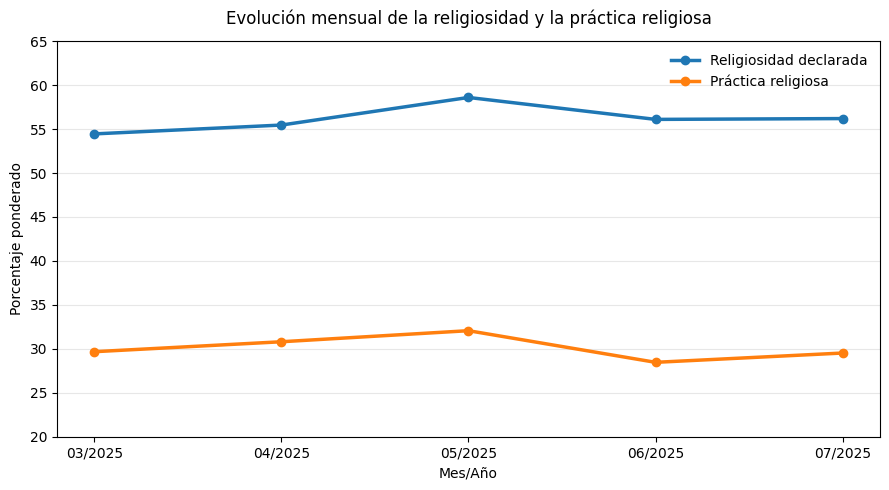

In [24]:
import matplotlib.pyplot as plt

serie_religiosidad = (
    df_total.groupby("Mes/Año")
    .apply(lambda x: media_ponderada(x["religiosidad_si_no"], x["Peso"]) * 100)
)

serie_practica = (
    df_total.loc[df_total["practica_religion_si_no"].notna()]
    .groupby("Mes/Año")
    .apply(lambda x: media_ponderada(x["practica_religion_si_no"], x["Peso"]) * 100)
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    serie_religiosidad.index,
    serie_religiosidad.values,
    marker="o",
    linewidth=2.5,
    label="Religiosidad declarada",
)

ax.plot(
    serie_practica.index,
    serie_practica.values,
    marker="o",
    linewidth=2.5,
    label="Práctica religiosa",
)

ax.set_title("Evolución mensual de la religiosidad y la práctica religiosa", pad=12)
ax.set_xlabel("Mes/Año")
ax.set_ylabel("Porcentaje ponderado")
ax.set_ylim(20, 65)
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


A continuación comparo la intención de voto de religiosos y no religiosos para ver si la dimensión religiosa también aparece asociada a diferencias políticas claras.


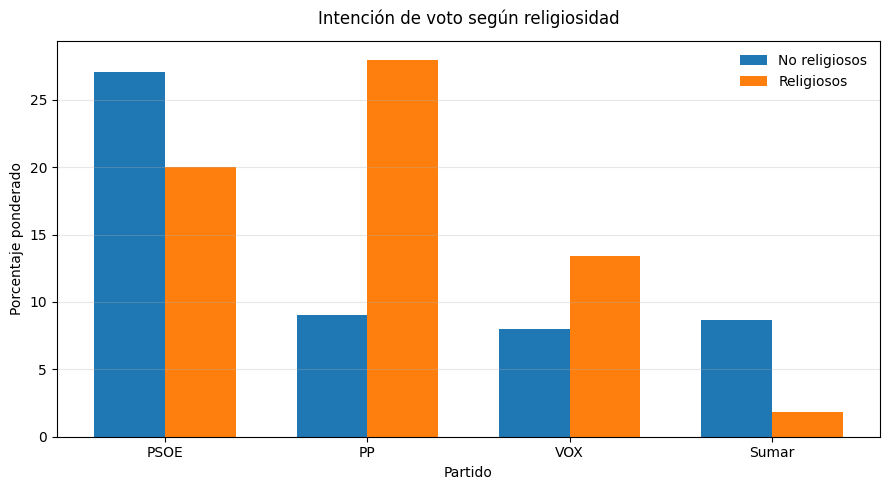

In [25]:
partidos_grafico = {
    "PSOE": "voto_psoe_si_no",
    "PP": "voto_pp_si_no",
    "VOX": "voto_vox_si_no",
    "Sumar": "voto_sumar_si_no",
}

tabla_voto_religiosidad_pond = pd.DataFrame({
    partido: [
        round(
            media_ponderada(
                df_total.loc[(df_total["religiosidad_si_no"].eq(grupo)) & df_total[variable].notna(), variable],
                df_total.loc[(df_total["religiosidad_si_no"].eq(grupo)) & df_total[variable].notna(), "Peso"],
            ) * 100,
            2,
        )
        for grupo in [0, 1]
    ]
    for partido, variable in partidos_grafico.items()
}, index=["No religiosos", "Religiosos"])

x = range(len(tabla_voto_religiosidad_pond.columns))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    [i - width / 2 for i in x],
    tabla_voto_religiosidad_pond.loc["No religiosos"],
    width=width,
    label="No religiosos",
)

ax.bar(
    [i + width / 2 for i in x],
    tabla_voto_religiosidad_pond.loc["Religiosos"],
    width=width,
    label="Religiosos",
)

ax.set_title("Intención de voto según religiosidad", pad=12)
ax.set_xlabel("Partido")
ax.set_ylabel("Porcentaje ponderado")
ax.set_xticks(list(x))
ax.set_xticklabels(tabla_voto_religiosidad_pond.columns)
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


Después comparo la ideología media de religiosos y no religiosos por mes, para ver si esa diferencia se mantiene estable a lo largo del periodo.


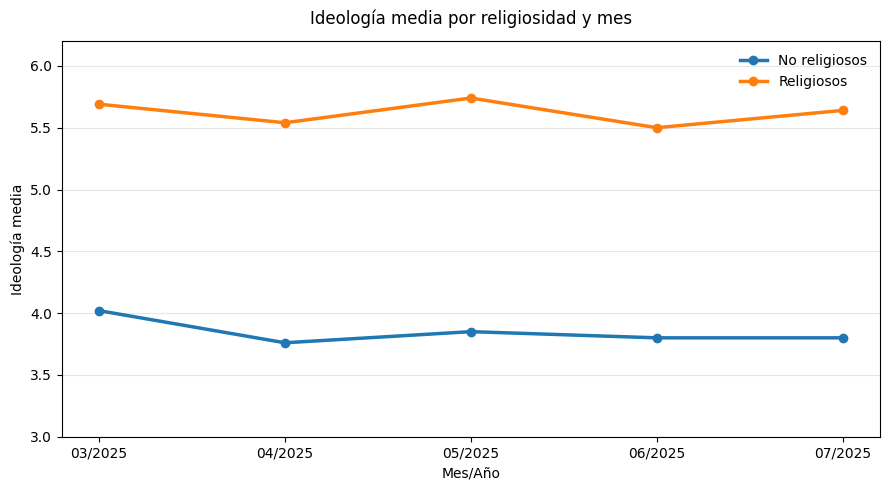

In [26]:
tabla_ideologia_mes = (
    df_total.groupby(["Mes/Año", "religiosidad_si_no"])["Ideologia"]
    .mean()
    .round(2)
    .unstack()
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    tabla_ideologia_mes.index,
    tabla_ideologia_mes[0],
    marker="o",
    linewidth=2.5,
    label="No religiosos",
)

ax.plot(
    tabla_ideologia_mes.index,
    tabla_ideologia_mes[1],
    marker="o",
    linewidth=2.5,
    label="Religiosos",
)

ax.set_title("Ideología media por religiosidad y mes", pad=12)
ax.set_xlabel("Mes/Año")
ax.set_ylabel("Ideología media")
ax.set_ylim(3, 6.2)
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


Por último, comparo algunos de los problemas que más diferencian a religiosos y no religiosos, para ver si la religiosidad también se relaciona con una forma distinta de priorizar la agenda pública.


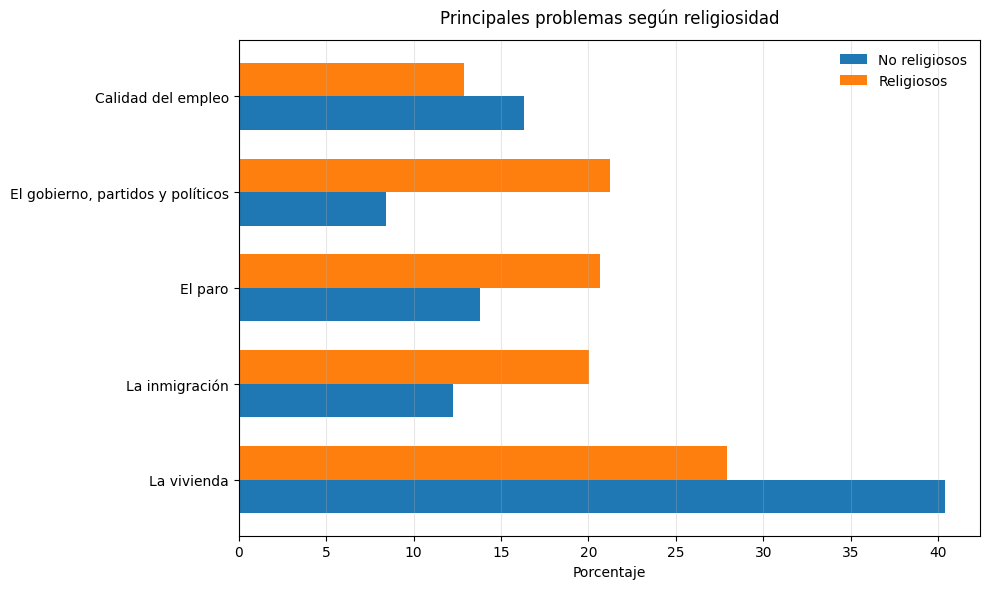

In [27]:
problemas_grafico = [
    "La vivienda",
    "La inmigración",
    "El paro",
    "El Gobierno y partidos o políticos/as concretos/as",
    "Los problemas relacionados con la calidad del empleo",
]

etiquetas_problemas = {
    "La vivienda": "La vivienda",
    "La inmigración": "La inmigración",
    "El paro": "El paro",
    "El Gobierno y partidos o políticos/as concretos/as": "El gobierno, partidos y políticos",
    "Los problemas relacionados con la calidad del empleo": "Calidad del empleo",
}

columnas_problemas = ["Problema_1", "Problema_2", "Problema_3"]

tabla_problemas_grafico = pd.DataFrame({
    etiquetas_problemas[problema]: [
        round(
            df_total.loc[df_total["religiosidad_si_no"].eq(grupo), columnas_problemas]
            .eq(problema)
            .any(axis=1)
            .mean() * 100,
            2,
        )
        for grupo in [0, 1]
    ]
    for problema in problemas_grafico
}, index=["No religiosos", "Religiosos"]).T

y = range(len(tabla_problemas_grafico.index))
height = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    [i - height / 2 for i in y],
    tabla_problemas_grafico["No religiosos"],
    height=height,
    label="No religiosos",
)

ax.barh(
    [i + height / 2 for i in y],
    tabla_problemas_grafico["Religiosos"],
    height=height,
    label="Religiosos",
)

ax.set_title("Principales problemas según religiosidad", pad=12)
ax.set_xlabel("Porcentaje")
ax.set_yticks(list(y))
ax.set_yticklabels(tabla_problemas_grafico.index)
ax.grid(axis="x", alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()
